# Análisis Exploratorio de Datos (EDA) - Cartera S&P 500

## Objetivo
Analizar la distribución, comportamiento y relaciones entre los KPIs
financieros de las 242 empresas candidatas seleccionadas en la fase SQL,
para extraer patrones que guíen la construcción de la cartera.

## Dataset
- Fuente: tabla `empresas_candidatas` exportada desde PostgreSQL
- Registros: 242 empresas
- Sectores: Technology, Healthcare, Energy, Basic Materials
- Variables: ROE, Net Profit Margin, Debt to Equity, PE Ratio, Revenue Growth

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos las empresas candidatas
df = pd.read_csv('/content/empresas_candidatas.csv')

kpis = ['roe', 'net_profit_margin', 'debt_to_equity', 'pe_ratio', 'revenue_growth']

print(f"Empresas candidatas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()

Empresas candidatas: 242
Columnas: 7


,ticker,sector,roe,net_profit_margin,debt_to_equity,pe_ratio,revenue_growth
0,CENX,Basic Materials,0.1144,0.0655,0.2305,18.6260,0.3278
1,CE,Basic Materials,0.2214,0.0917,0.9663,14.8784,0.0449
2,SLCA,Basic Materials,0.3010,0.1386,1.2260,11.3673,0.6058
3,LYB,Basic Materials,0.5020,0.0915,0.8474,9.8867,0.0351
4,MEOH,Basic Materials,0.2545,0.1410,0.9971,9.5678,0.0659


In [2]:
# Estadísticas descriptivas de los KPIs
print("=== ESTADÍSTICAS DESCRIPTIVAS ===\n")
print(df[kpis].describe().round(4))

=== ESTADÍSTICAS DESCRIPTIVAS ===

            roe  net_profit_margin  debt_to_equity  pe_ratio  revenue_growth
count  242.0000           242.0000        242.0000  242.0000        242.0000
mean     0.1919             0.1763          0.4894   21.3003          0.2407
std      0.1123             0.1037          0.4962   10.0431          0.3188
min      0.0501             0.0318          0.0000    5.5053          0.0047
25%      0.1225             0.1021          0.0237   14.4710          0.0730
50%      0.1645             0.1531          0.3480   19.6530          0.1368
75%      0.2288             0.2170          0.7702   25.8391          0.2555
max      0.8690             0.7214          2.4589   59.0490          2.6924


### Hallazgos de las estadísticas descriptivas

- **ROE medio: 19,19%** — rentabilidad sólida, con empresas que llegan hasta el 86,9%
- **Margen neto medio: 17,63%** — empresas con buena conversión de ventas a beneficio
- **Deuda/Equity media: 0,49** — apalancamiento moderado en el conjunto
- **PE ratio medio: 21,3** — valoración razonable de mercado
- **Crecimiento medio: 24,07%** — alto crecimiento, con casos extremos hasta el 269%
- **La desviación estándar del revenue growth (0,32) es mayor que la media** —
  alta dispersión, lo que indica que algunas empresas crecen muy por encima de la media

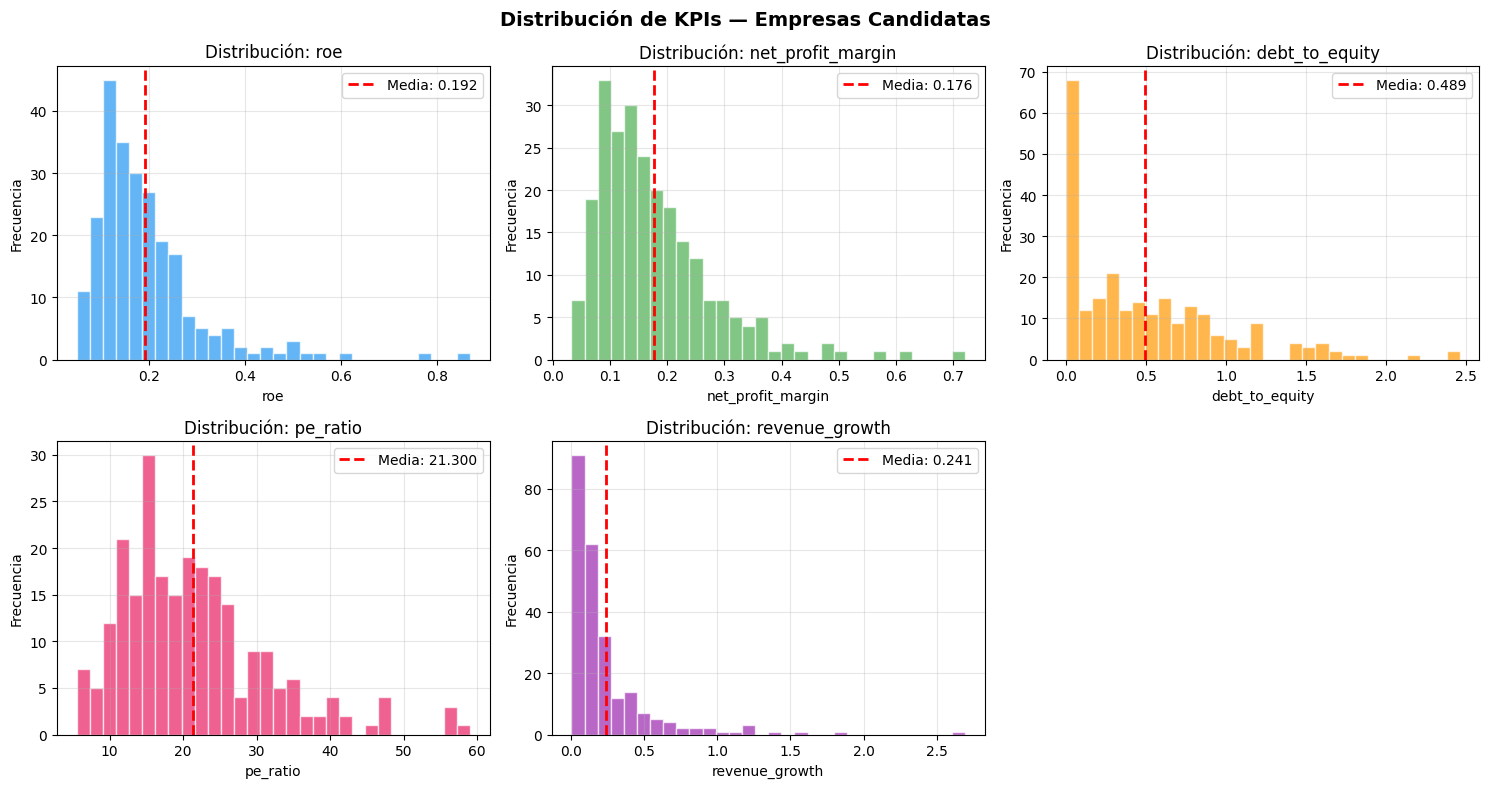

In [3]:
# Distribución de cada KPI
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colores = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for i, (kpi, color) in enumerate(zip(kpis, colores)):
    axes[i].hist(df[kpi], bins=30, color=color, alpha=0.7, edgecolor='white')
    axes[i].set_title(f'Distribución: {kpi}')
    axes[i].set_xlabel(kpi)
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(df[kpi].mean(), color='red', linestyle='--',
                    linewidth=2, label=f'Media: {df[kpi].mean():.3f}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[5].set_visible(False)
plt.suptitle('Distribución de KPIs — Empresas Candidatas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

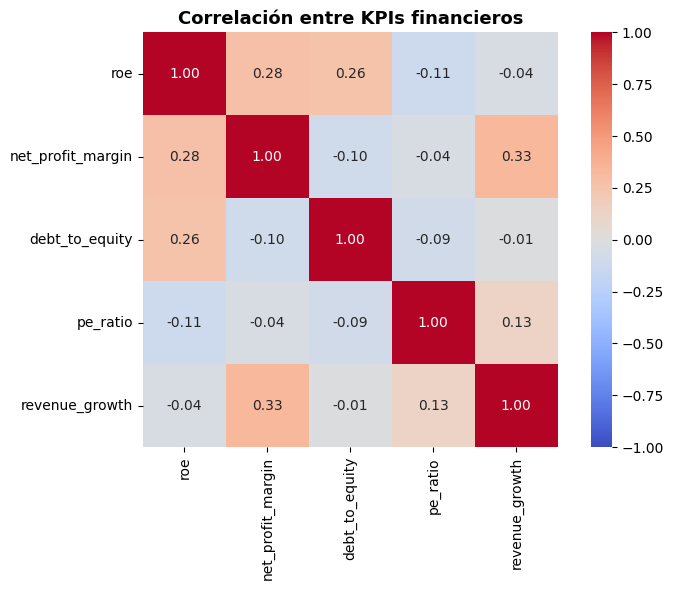

In [4]:
# Mapa de correlaciones entre KPIs
plt.figure(figsize=(8, 6))
correlaciones = df[kpis].corr().round(2)

sns.heatmap(correlaciones,
            annot=True,
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            fmt='.2f',
            square=True)

plt.title('Correlación entre KPIs financieros', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

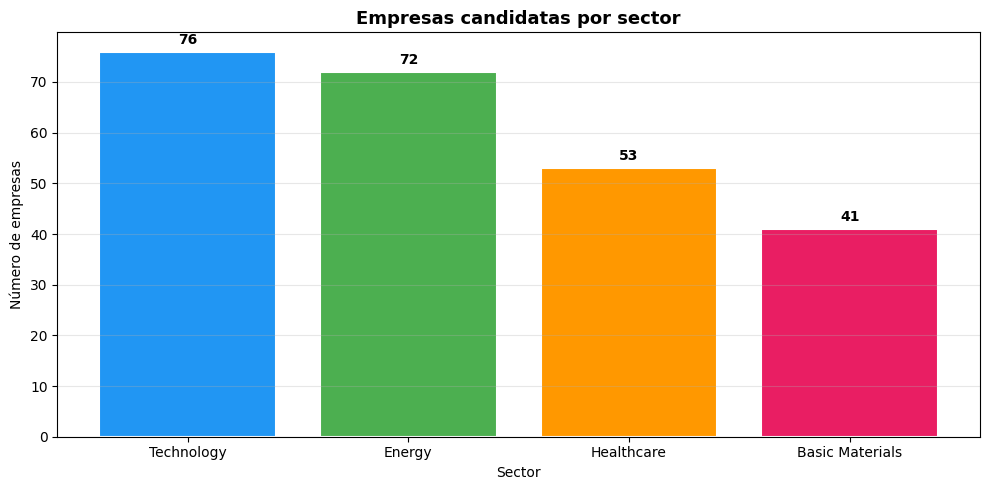

In [5]:
# Distribución de empresas por sector
plt.figure(figsize=(10, 5))

colores_sector = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
conteo = df['sector'].value_counts()

bars = plt.bar(conteo.index, conteo.values, color=colores_sector,
               edgecolor='white', linewidth=1.5)

for bar, valor in zip(bars, conteo.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(valor), ha='center', va='bottom', fontweight='bold')

plt.title('Empresas candidatas por sector', fontsize=13, fontweight='bold')
plt.xlabel('Sector')
plt.ylabel('Número de empresas')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Conclusiones del EDA

### Distribuciones
- Los KPIs muestran distribuciones asimétricas hacia la derecha típicas
  de datos financieros — la mayoría de empresas se concentra en valores
  moderados con pocos casos excepcionales que tiran de la media
- El Revenue Growth es el KPI más disperso (std=0,32 > media=0,24),
  indicando alta variabilidad en el crecimiento entre empresas candidatas
- El Debt to Equity está muy concentrado cerca de 0, confirmando que
  los filtros SQL seleccionaron empresas con bajo apalancamiento

### Correlaciones
- Las correlaciones entre KPIs son moderadas o bajas (máximo 0,33)
- La relación más fuerte es Net Profit Margin ↔ Revenue Growth (0,33):
  empresas con mejor margen tienden a crecer más
- La independencia entre variables justifica el uso de los 5 KPIs
  en PCA y K-Means sin riesgo de multicolinealidad

### Distribución por sector
- Technology (76) y Energy (72) dominan el universo candidato
- Healthcare (53) y Basic Materials (41) están menos representados
- La distribución equilibrada entre sectores garantiza diversificación